<a href="https://colab.research.google.com/github/Sambarlasagna/ComputerVision_Pytorch/blob/main/ptorch_custom_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
torch.__version__
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device )

cuda


In [2]:
#Get data
import requests
import zipfile
from pathlib import Path

#Setup to a data folder
data_path = Path("data/")
image_path = data_path/"pizza_steak_sushi"

#if the image folder doest exist, download it and prepre it....
if image_path.is_dir():
  print(f"{image_path} directory already exists... skipping download")
else:
  print(f"Did not find {image_path} directory,creating one...")
  image_path.mkdir(parents=True,exist_ok = True)

#download pizza,steak and sushi data
with open(data_path / "pizza_steak_sushi.zip","wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print("Downloading data..")
  f.write(request.content)
#unzip file
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip","r") as zip_ref:
  print("Unziping pizza,steak and sushi data...")
  zip_ref.extractall(image_path)

Did not find data/pizza_steak_sushi directory,creating one...
Unziping pizza,steak and sushi data...


### data prep and exploration


In [3]:
import os
def walk_through_dir(dir_path):
  for dirpath,dirnames,filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")
walk_through_dir(image_path)


There are 2 directories and 0 images in 'data/pizza_steak_sushi'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'


In [4]:
#setup train and testing paths
train_dir = image_path /"train"
test_dir = image_path/"test"

train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

Random image path:data/pizza_steak_sushi/train/pizza/2576168.jpg
Image class:pizza
Image height:384
Image width: 512


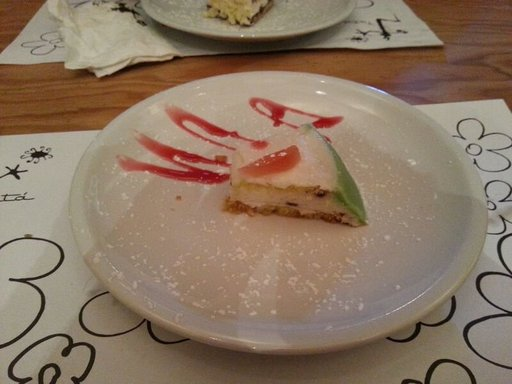

In [5]:
import random
from PIL import Image

# random.seed(42)

image_path_list = list(image_path.glob("*/*/*.jpg"))

random_image_path = random.choice(image_path_list)

image_class = random_image_path.parent.stem

img = Image.open(random_image_path)

print(f"Random image path:{random_image_path}")
print(f"Image class:{image_class}")
print(f"Image height:{img.height}")
print(f"Image width: {img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

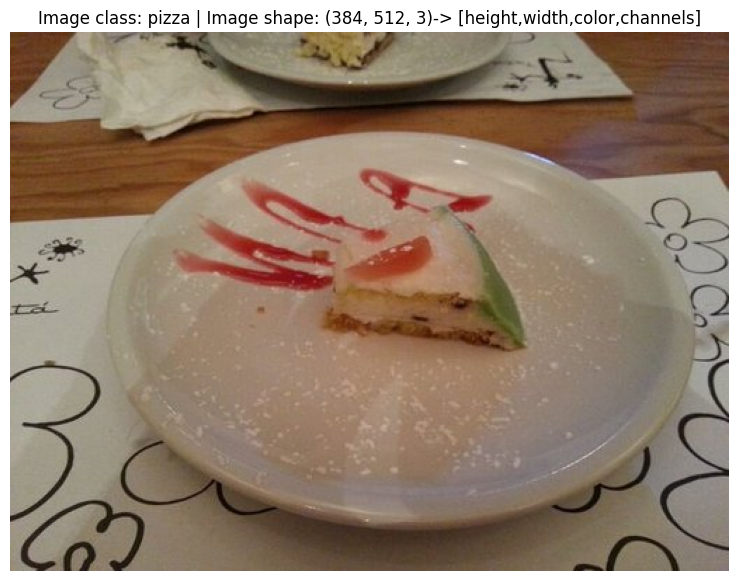

In [6]:
import numpy as np
import matplotlib.pyplot as plt

img_as_array = np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape}-> [height,width,color,channels]")
plt.axis(False)

array([[[102,  65,  38],
        [102,  65,  36],
        [102,  65,  36],
        ...,
        [ 91,  56,  34],
        [ 90,  55,  33],
        [ 92,  57,  35]],

       [[ 97,  60,  33],
        [ 97,  60,  31],
        [ 97,  61,  29],
        ...,
        [ 90,  55,  33],
        [ 89,  54,  34],
        [ 90,  55,  33]],

       [[ 95,  58,  29],
        [ 95,  59,  27],
        [ 95,  59,  27],
        ...,
        [ 88,  56,  35],
        [ 88,  55,  36],
        [ 90,  58,  37]],

       ...,

       [[152, 140, 118],
        [153, 141, 119],
        [153, 142, 122],
        ...,
        [134, 120, 119],
        [134, 120, 119],
        [134, 120, 119]],

       [[149, 137, 113],
        [152, 140, 116],
        [153, 142, 120],
        ...,
        [134, 120, 120],
        [132, 118, 118],
        [131, 117, 117]],

       [[148, 136, 112],
        [152, 140, 116],
        [154, 143, 121],
        ...,
        [136, 122, 122],
        [134, 119, 122],
        [131, 116, 119]]], dtype=uint8)
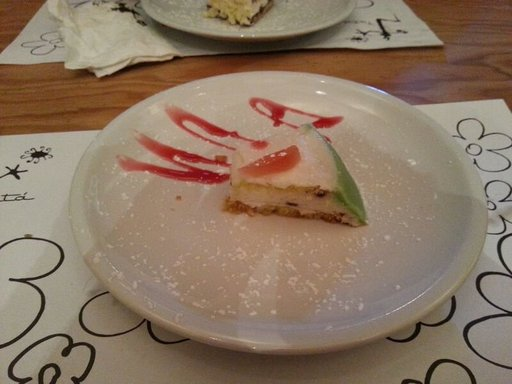

In [7]:
img_as_array

In [8]:
#3. Transforming data
import torch
from torch.utils.data import DataLoader
from torchvision import datasets,transforms

In [9]:
#Write transform for image
data_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
    ])

In [10]:
data_transform(img)

tensor([[[0.3725, 0.3843, 0.3843,  ..., 0.4000, 0.3922, 0.3922],
         [0.3961, 0.4000, 0.3882,  ..., 0.4078, 0.4000, 0.4078],
         [0.4078, 0.4118, 0.4039,  ..., 0.4078, 0.4078, 0.4039],
         ...,
         [0.4118, 0.4706, 0.5255,  ..., 0.5961, 0.3922, 0.5451],
         [0.5294, 0.5333, 0.5294,  ..., 0.5333, 0.3569, 0.5412],
         [0.5294, 0.5294, 0.5216,  ..., 0.2784, 0.4431, 0.5843]],

        [[0.2392, 0.2431, 0.2353,  ..., 0.2275, 0.2275, 0.2431],
         [0.2627, 0.2627, 0.2549,  ..., 0.2353, 0.2314, 0.2431],
         [0.2627, 0.2667, 0.2745,  ..., 0.2471, 0.2353, 0.2275],
         ...,
         [0.3725, 0.4275, 0.4863,  ..., 0.5647, 0.3529, 0.5176],
         [0.4902, 0.4902, 0.4902,  ..., 0.4980, 0.3176, 0.5098],
         [0.4784, 0.4863, 0.4824,  ..., 0.2353, 0.4118, 0.5490]],

        [[0.1725, 0.1882, 0.1804,  ..., 0.1294, 0.1294, 0.1137],
         [0.2039, 0.1922, 0.1922,  ..., 0.1176, 0.1333, 0.1255],
         [0.1882, 0.1882, 0.2078,  ..., 0.1373, 0.1373, 0.

In [11]:
def plot_transformed_images(image_paths: list,transform,n=3,seed=None):
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths,k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows=1,ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original\nSize: {f.size}")
      ax[0].axis(False)

      transformed_image = transform(f).permute(1,2,0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
      ax[1].axis("off")

      fig.suptitle(f"Class: {image_path.parent.stem}",fontsize=16)

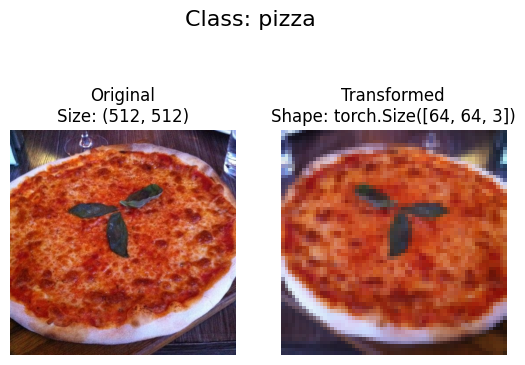

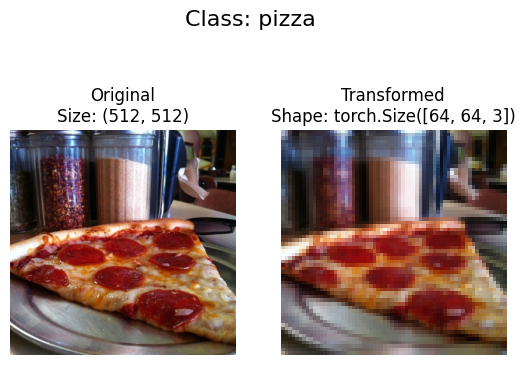

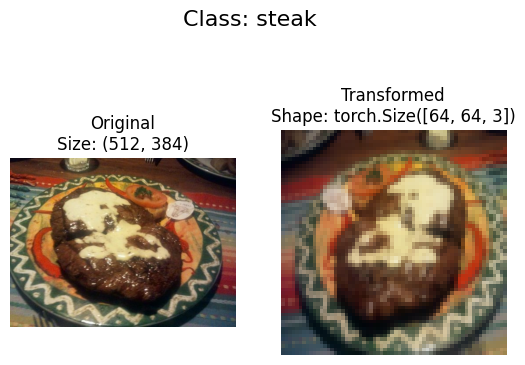

In [12]:
plot_transformed_images(image_path_list,
                        data_transform,3,42 )

In [13]:
#use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,transform=data_transform,
                                  target_transform=None)
test_data = datasets.ImageFolder(root=test_dir,
                                 transform = data_transform)
train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [14]:
class_names = train_data.classes
class_dict = train_data.class_to_idx
class_names,class_dict

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [15]:
len(train_data),train_data.samples[0],len(test_data),test_data.samples[0]

(225,
 ('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0),
 75,
 ('data/pizza_steak_sushi/test/pizza/1152100.jpg', 0))

In [16]:
img,label = train_data[0][0],train_data[0][1]
print(f"Image tensor:\n {img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Image class: {class_names[label]}")
print(f"Label datatype: {type(label)}")

Image tensor:
 tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.0

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute shape: torch.Size([64, 64, 3]) -> [height, width, color_channels]


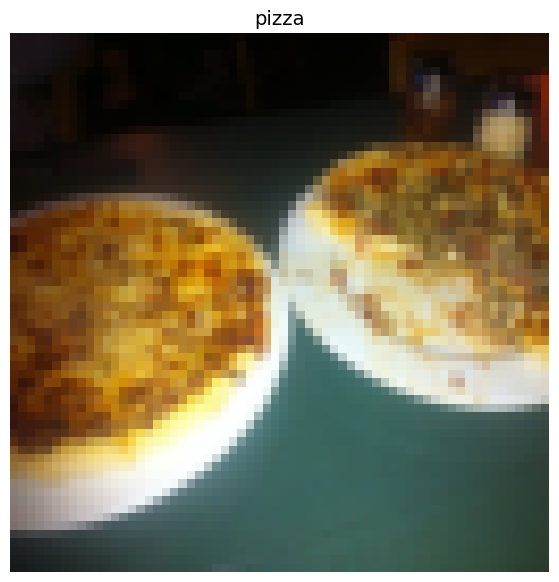

In [17]:
# Rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)

# Print out different shapes (before and after permute)
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.title(class_names[label], fontsize=14);

In [18]:
import os
os.cpu_count()

2

In [19]:
from torch.utils.data import DataLoader
BATCH_SIZE=32
train_dataloader = DataLoader(dataset = train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=1,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size =BATCH_SIZE,
                             shuffle=False)
print(len(train_dataloader),len(test_dataloader))
len(train_data),len(test_data)

8 3


(225, 75)

In [20]:
img,label = next(iter(train_dataloader))
print(f"Image shape: {img.shape} -> [batch_size,color_channels,height,width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([32, 3, 64, 64]) -> [batch_size,color_channels,height,width]
Label shape: torch.Size([32])


#3 Loading Image Data with a Custom `Dataset`

In [21]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple,Dict, List



In [22]:
train_data.classes,train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [23]:
#5.1 Creatingn a helper function to get class names
target_directory = train_dir
print(f"Target dir: {target_directory}")

class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found



Target dir: data/pizza_steak_sushi/train


['pizza', 'steak', 'sushi']

In [24]:
def find_classes(directory:str)-> Tuple[List[str], Dict[str,int]]:
  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

  if not classes:
    raise FileNotFoundError(f"Couldn't find any classes in {directory}")
  class_to_idx = {cls_name:i for i,cls_name in enumerate(classes)}
  return classes,class_to_idx
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [25]:
from torch.utils.data import Dataset
class ImageFolderCustom(Dataset):
    def __init__(self,
                targ_dir:str,transform=None):
     self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
     self.transform = transform
     self.classes,self.class_to_idx = find_classes(targ_dir)

    def load_image(self,index: int)->Image.Image:
      image_path = self.paths[index]
      return Image.open(image_path)

    def __len__(self)->int:
      return len(self.paths)

    def __getitem__(self,index:int)->Tuple[torch.Tensor, int]:
      img = self.load_image(index)
      class_name = self.paths[index].parent.name
      class_idx = self.class_to_idx[class_name]

      if self.transform:
        return self.transform(img), class_idx
      else:
        return img,class_idx


In [26]:
from torchvision import transforms
train_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [27]:
train_data_custom = ImageFolderCustom(targ_dir = train_dir,
                                      transform = train_transforms)
test_data_custom = ImageFolderCustom(targ_dir = test_dir,
                                    transform = test_transforms)

In [28]:
train_data_custom,test_data_custom

(<__main__.ImageFolderCustom at 0x7c6290f75280>,
 <__main__.ImageFolderCustom at 0x7c6290f145c0>)

In [29]:
len(train_data),len(train_data_custom)

(225, 225)

In [30]:
len(test_data),len(test_data_custom)

(75, 75)

In [31]:
test_data_custom.classes,test_data_custom.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [32]:
#Check for equality
print(train_data_custom.classes==train_data.classes)
print(test_data_custom.classes==test_data.classes)

True
True


### 5.3 Create a function to display random images

In [33]:
#5.3 Create a function to display random images
def display_random_images(dataset:torch.utils.data.Dataset,
                          classes:List[str]=None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int= None):
  if n>10:
    n = 10
    display_shape = False
    print(f"For display, purposes, shudnt be larger than 10, setting to 10 and removign shape display")

  if seed:
    random.seed (seed)

  random_samples_idx = random.sample(range(len(dataset)),k=n)

  plt.figure(figsize=(16,8))

  for i,targ_sample in enumerate(random_samples_idx):
    targ_image,targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

    targ_image_adjust = targ_image.permute(1,2,0) #from chw to hwc

    plt.subplot(1,n,i+1) # Changed n/2 to (n+1)//2 to handle odd n
    plt.imshow(targ_image_adjust)
    if classes:
      title = f"Class: {classes[targ_label]}\n"
      if display_shape:
        title = title + f"Shape: {targ_image_adjust.shape}"
      plt.title(title)
      plt.axis("off")

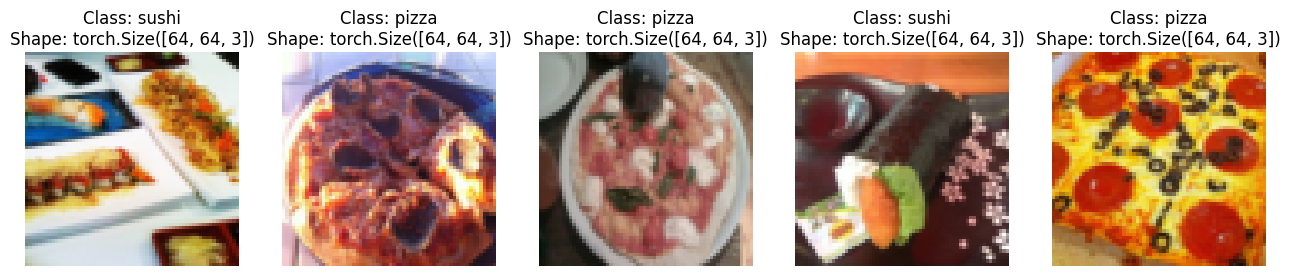

In [34]:
display_random_images(train_data,
                      n=5,
                      classes=class_names,
                      seed=42)


For display, purposes, shudnt be larger than 10, setting to 10 and removign shape display


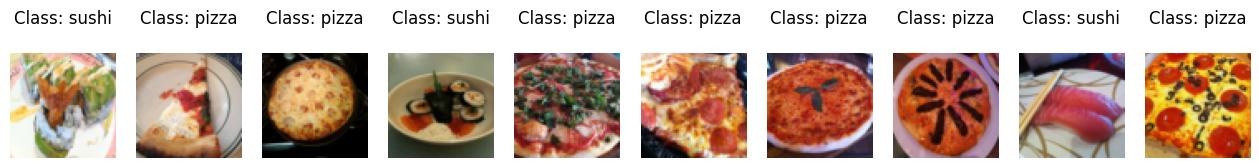

In [35]:
display_random_images(train_data_custom,
                      n=20,
                      classes=class_names,
                      seed=42)

### 5.4 Turn custom laded images into `DataLoader`'s

In [36]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
train_dataloader_custom = DataLoader(dataset = train_data_custom,
                                     batch_size = BATCH_SIZE,
                                     num_workers = NUM_WORKERS,
                                     shuffle = True)
test_dataloader_custom = DataLoader(dataset = test_data_custom,
                                    batch_size = BATCH_SIZE,
                                    num_workers = NUM_WORKERS,
                                    shuffle = False)
train_dataloader_custom,test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7c6290b83f20>,
 <torch.utils.data.dataloader.DataLoader at 0x7c6290e48e30>)

In [37]:
#Get image and label from customddataloader
img_custom,label_custom = next(iter(train_dataloader_custom))

#print out the shapes
img_custom.shape,label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

### Data augmentation



In [45]:
from torchvision import transforms

train_transform = transforms.Compose([ transforms.Resize(size=(224,224)),
                                        transforms.TrivialAugmentWide(num_magnitude_bins=31),
                                        transforms.ToTensor()
])
test_transform = transforms.Compose([transforms.Resize(size=(224,224)),
                                      transforms.ToTensor()
])

In [42]:
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/train/pizza/2426686.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/138855.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/1633289.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/218711.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/220190.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/3860002.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/3196721.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/1089334.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/300869.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/2428085.jpg')]

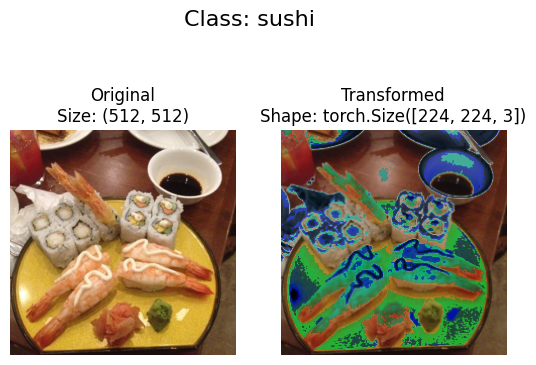

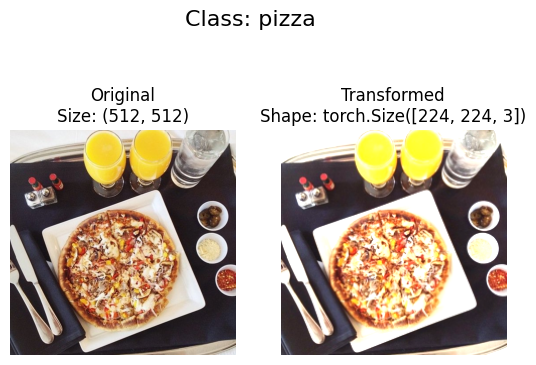

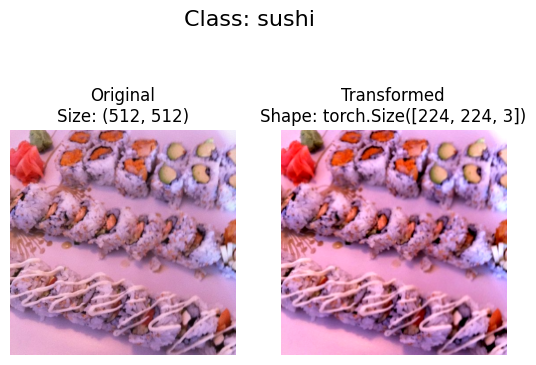

In [46]:
plot_transformed_images(image_paths = image_path_list,
                          transform = train_transform,
                          n=3,
                          seed=None)